# MCD Evaluation (Common Taxonomy)

Evaluates BKI semantic mapping results on the MCD dataset.
Both GT and predicted labels are in the 11-class common taxonomy (see `config/datasets/labels_common.yaml`).

In [34]:
import glob
import os
import numpy as np
from sklearn.metrics import jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ---------- Configuration ----------
# Path to the evaluations folder (written by mcd_node query_scan)
DATA_DIR = "/media/donceykong/doncey_ssd_011/datasets/"
DATASET_NAME = "mcd"
SEQUENCE_NAME = "kth_day_09" # kitti360: "2013_05_28_drive_####_sync", mcd: "kth_<day/night>_##"
EVAL_PREFIX = "terrain_vanilla"

EVALUATION_DIR = os.path.join(DATA_DIR, f"{DATASET_NAME}/{SEQUENCE_NAME}/evaluations/{EVAL_PREFIX}")  # change to osm_kernel if using OSM-optimized labels

# Common taxonomy class names (index = class ID, from labels_common.yaml)
COMMON_CLASSES = [
    "unlabeled",     # 0
    "road",          # 1
    "sidewalk",      # 2
    "parking",       # 3
    "building",      # 4
    "fence",         # 5
    "pole",          # 6
    "traffic-sign",  # 7
    "vegetation",    # 8
    "vehicle",       # 9
    "terrain",       # 10
]
NUM_CLASSES = len(COMMON_CLASSES)

## Load evaluation results

In [36]:
# Discover all evaluation .txt files (MCD uses 10-digit scan IDs)
result_files = sorted(glob.glob(os.path.join(EVALUATION_DIR, "*.txt")))
print(f"Found {len(result_files)} evaluation files in {EVALUATION_DIR}")

gt_all = []
pred_all = []
for fpath in result_files:
    result = np.loadtxt(fpath, dtype=np.int32)
    if result.ndim == 1:
        result = result.reshape(1, -1)
    gt_all.append(result[:, 0])
    pred_all.append(result[:, 1])

gt_all = np.concatenate(gt_all)
pred_all = np.concatenate(pred_all)
print(f"Total points: {len(gt_all)}")
print(f"Unique GT classes:   {np.unique(gt_all)}")
print(f"Unique pred classes: {np.unique(pred_all)}")

Found 1947 evaluation files in /media/donceykong/doncey_ssd_011/datasets/mcd/kth_night_05/evaluations/terrain_vanilla
Total points: 127598592
Unique GT classes:   [ 0  1  2  3  4  5  6  7  8  9 10]
Unique pred classes: [ 0  1  2  3  4  5  6  7  8  9 10]


## Per-class IoU

In [37]:
# Filter out unlabeled (class 0)
mask = gt_all != 0
gt_eval = gt_all[mask]
pred_eval = pred_all[mask]
print(f"Points after removing unlabeled: {len(gt_eval)}")

# Compute per-class IoU over all semantic classes (1-12)
semantic_classes = np.arange(1, NUM_CLASSES)
iou_scores = jaccard_score(gt_eval, pred_eval, labels=semantic_classes, average=None, zero_division=0)

# Per-class accuracy (recall): TP / (TP + FN) = correct predictions / GT count
per_class_acc = np.zeros(len(semantic_classes))
for i, cls_id in enumerate(semantic_classes):
    cls_mask = gt_eval == cls_id
    if cls_mask.sum() > 0:
        per_class_acc[i] = (pred_eval[cls_mask] == cls_id).sum() / cls_mask.sum()

# Per-class precision: TP / (TP + FP) = correct predictions / Pred count
per_class_prec = np.zeros(len(semantic_classes))
for i, cls_id in enumerate(semantic_classes):
    pred_mask = pred_eval == cls_id
    if pred_mask.sum() > 0:
        per_class_prec[i] = (gt_eval[pred_mask] == cls_id).sum() / pred_mask.sum()

print(f"\n{'Class':>3}  {'Name':<15s}  {'IoU':>8s}  {'Accuracy':>10s}  {'Precision':>10s}  {'GT count':>10s}  {'Pred count':>10s}")
print("-" * 80)
for i, cls_id in enumerate(semantic_classes):
    gt_count = np.sum(gt_eval == cls_id)
    pred_count = np.sum(pred_eval == cls_id)
    print(f"{cls_id:>3d}  {COMMON_CLASSES[cls_id]:<15s}  {iou_scores[i]:>8.4f}  {per_class_acc[i]:>10.4f}  {per_class_prec[i]:>10.4f}  {gt_count:>10d}  {pred_count:>10d}")

# Only average over classes that appear in GT
present_mask = np.array([np.sum(gt_eval == c) > 0 for c in semantic_classes])
miou = np.mean(iou_scores[present_mask]) if present_mask.any() else 0.0
mean_acc = np.mean(per_class_acc[present_mask]) if present_mask.any() else 0.0
mean_prec = np.mean(per_class_prec[present_mask]) if present_mask.any() else 0.0

print(f"\nmIoU (over {present_mask.sum()} present classes):       {miou:.4f}")
print(f"Mean accuracy (recall):                  {mean_acc:.4f}")
print(f"Mean precision:                          {mean_prec:.4f}")
print(f"Overall accuracy:                        {np.mean(gt_eval == pred_eval):.4f}")

Points after removing unlabeled: 103419245

Class  Name                  IoU    Accuracy   Precision    GT count  Pred count
--------------------------------------------------------------------------------
  1  road               0.1237      0.8626      0.1262     3034239    20734673
  2  sidewalk           0.0486      0.0513      0.4811    23224639     2475279
  3  parking            0.0000      0.0000      0.0000       91624     1025014
  4  building           0.8031      0.8444      0.9425    57961766    51928379
  5  fence              0.0128      0.0354      0.0196      416627      752031
  6  pole               0.1840      0.2092      0.6039      595689      206415
  7  traffic-sign       0.0916      0.1029      0.4555      336318       75955
  8  vegetation         0.5788      0.7652      0.7038    12885123    14008197
  9  vehicle            0.0942      0.1190      0.3112     2201084      841435
 10  terrain            0.2305      0.3948      0.3565     2672136     2958886

mIo

## IoU bar chart

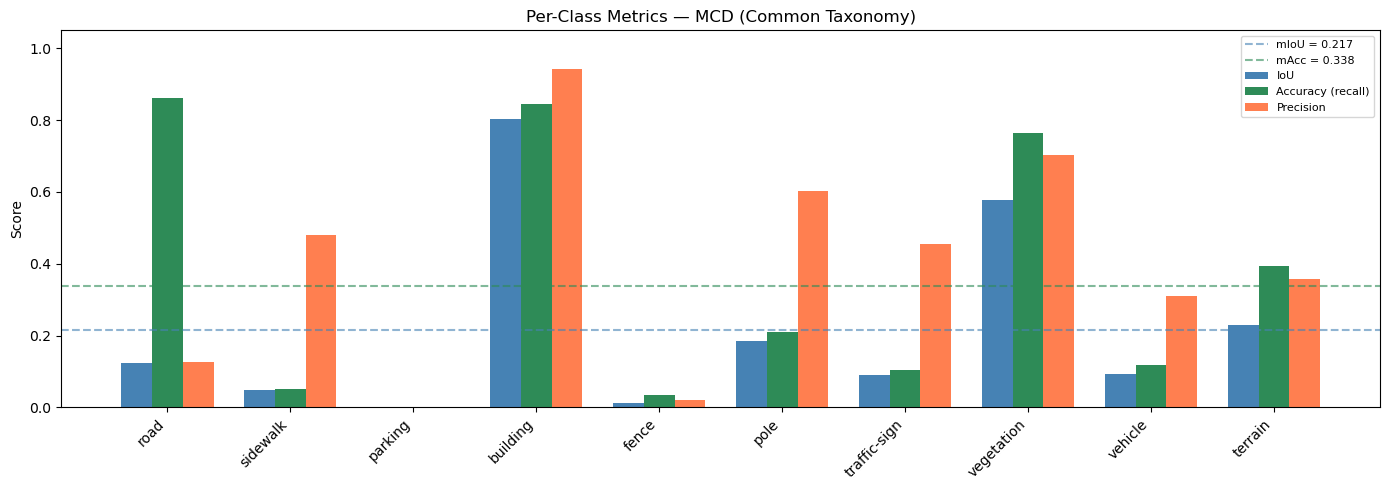

In [38]:
class_names = [COMMON_CLASSES[c] for c in semantic_classes]
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, iou_scores, width, label="IoU", color="steelblue")
ax.bar(x,         per_class_acc, width, label="Accuracy (recall)", color="seagreen")
ax.bar(x + width, per_class_prec, width, label="Precision", color="coral")

ax.axhline(miou, color="steelblue", linestyle="--", alpha=0.6, label=f"mIoU = {miou:.3f}")
ax.axhline(mean_acc, color="seagreen", linestyle="--", alpha=0.6, label=f"mAcc = {mean_acc:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics — MCD (Common Taxonomy)")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Confusion matrix

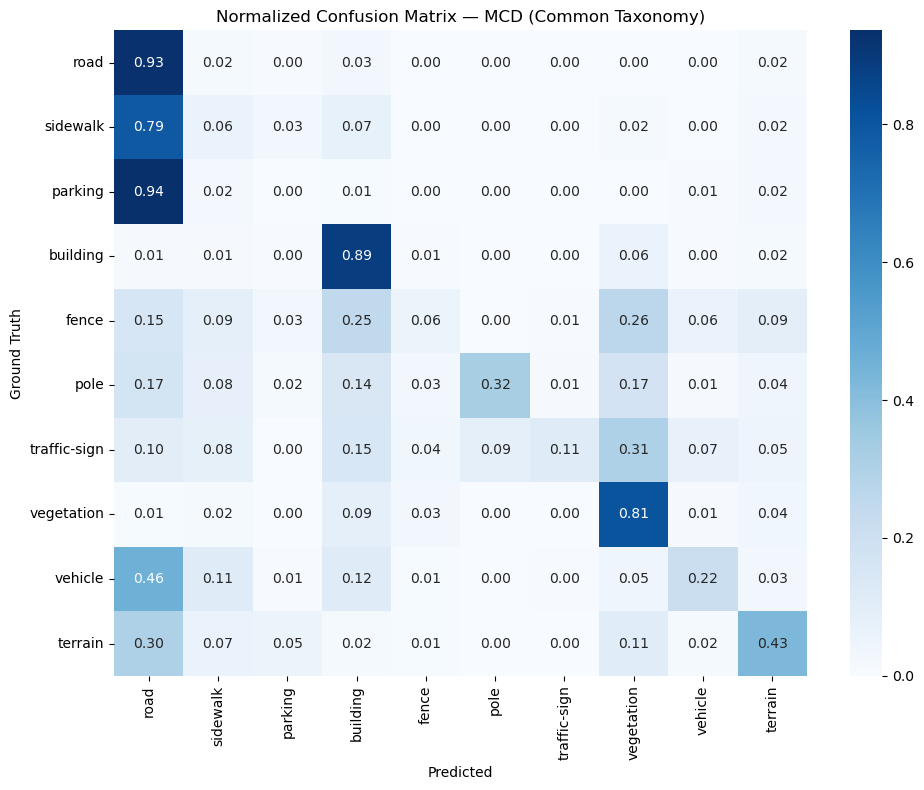

In [39]:
cm = confusion_matrix(gt_eval, pred_eval, labels=semantic_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground Truth")
ax.set_title("Normalized Confusion Matrix — MCD (Common Taxonomy)")
plt.tight_layout()
plt.show()